In [9]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from cosmographi.utils.perturbations import generate_perturbations_vector
import jax.numpy as jnp 
from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.instrument.rubin import RubinObservatory
from scipy.optimize import minimize
import numpy as np
import cosmographi as cp
import jax
import matplotlib.pyplot as plt
from cosmographi.utils.constants import M_sun, c_nm
from cosmographi.utils.flux import convert_to_jy
jax.config.update("jax_enable_x64", True)
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import pandas as pd
from tinygp import GaussianProcess, kernels
from cosmographi.utils.perturbations import generate_perturbations_vector


In [10]:
def generate_perturbations_vector(alpha, n_samples, sample_rate=1.0, seed: int | None = None):
    """
    Generates 1D colored noise and plots the transformation steps.

    Parameters:
    alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
    n_samples (int): Number of data points to generate.
    sample_rate (float): Assumed sample rate for frequency calculation.
    """
    rng = np.random.default_rng(seed=seed)
    white_noise = rng.normal(0, 1, n_samples)
    fft_white = jnp.fft.rfft(white_noise)
    frequencies = jnp.fft.rfftfreq(n_samples, d=1/sample_rate)
    # Ignore divide by zero for the DC component (f=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Amplitude scales as 1/f^(alpha/2)
        scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))
    scaling_factor = scaling_factor.at[0].set(0.0)
    fft_colored = fft_white * scaling_factor
    colored_noise = jnp.fft.irfft(fft_colored, n=n_samples)
    exp = jnp.exp(colored_noise)
    return exp / jnp.mean(exp)

In [11]:
def generate_perturbations_gp(scale: float, noise: float, num_samples: int, key = None) -> jnp.ndarray:
    x = jnp.arange(num_samples)
    kernel = kernels.stationary.Exp(scale=scale)
    gp = GaussianProcess(kernel, x, diag=noise**2)
    samples = gp.sample(key)
    return jnp.exp(samples) / jnp.mean(jnp.exp(samples))

In [12]:

def compute_neg_log_likelihood(x: tuple[float], observed_flux: jnp.ndarray, times: jnp.ndarray, 
                           band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, 
                           blackhole_mass: float, accretion_rate: float, inclination_angle: float, rin_to_rng: float, z: float, noise_var = None) -> float: 
    """ Must pass with same format as Instrument.observe
    """
    start_time, end_time = (times[0], times[-1])
    if len(x) == 2:
        proposed_alpha, num_perturbation_samples = x
    else:
        proposed_alpha, num_perturbation_samples, noise_var = x
    num_perturbation_samples = max(int(round(num_perturbation_samples)), 2)
    sample_rate = num_perturbation_samples / (end_time - start_time)
    perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, sample_rate=sample_rate, seed=42)
    agn = AGNSourceLipunova2018(blackhole_mass=blackhole_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=rin_to_rng, inclination_angle=inclination_angle)
    rubin = RubinObservatory()
    rubin.throughput.trim()
    rubin.throughput.to_dynamic() 
    band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, band, return_dict=True)
    key = jax.random.key(42)
    agn.t0 = start_time
    C = cp.cosmology.Cosmology()
    agn.z = z
    agn.cosmology = C
    agn.mu = agn.cosmology.distance_modulus(z)
    source_values = jnp.asarray(agn.get_values())
    survey_values = jnp.asarray(rubin.get_values())    
    obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
    model_flux = obs(key, band, exp_time, sky_brightness, PSF_Aeff, agn, times, source_values, survey_values)[2]  
    def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
    band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
    band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
    zero_points = jnp.array([band_id_to_zero[i]for i in range(len(band_id_to_zero))])
    model_flux_jansky = convert_to_jy(model_flux, band, zero_points, rubin.effective_aperture)
    model_flux_comparable_units = model_flux_jansky * 1e9
    n = len(observed_flux)
    ll = (- n/2 * jnp.log(2*jnp.pi) - n/2 * jnp.log(noise_var) - 1/2/noise_var * jnp.sum((model_flux_comparable_units - observed_flux) ** 2)) * (-1)
    return float(ll)


def minimize_log_likelihood(observed_flux: jnp.ndarray, times: jnp.ndarray, band: jnp.ndarray, exp_time: jnp.ndarray, 
                            sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, blackhole_mass: float, accretion_rate: float, 
                            inclination_angle: float, z: float, noise_var: float | None = None, rin_to_rng: float = 6) -> float:
    if noise_var is None:
        bounds = [(0.0, 2.0), (2.0, None), (1e-12, None)]
        args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z)
        x0 = np.asarray([0.88, (times[-1] - times[0])/ len(times), 3])
        results = minimize(compute_neg_log_likelihood, x0, args, method="Powell", bounds=bounds)
    else:
        bounds = [(0.0, 2.0), (2.0, None)]
        args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z, noise_var)
        x0 = np.asarray([0.88, (times[-1] - times[0])/ len(times)])
        results = minimize(compute_neg_log_likelihood, x0, args, method="Powell", bounds=bounds)
    return results

In [13]:
def compute_neg_log_likelihood_gp(x: tuple[float], observed_flux: jnp.ndarray, times: jnp.ndarray, 
                           band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, 
                           blackhole_mass: float, accretion_rate: float, inclination_angle: float, rin_to_rng: float, z: float, noise_var = None) -> float: 
    """ Must pass with same format as Instrument.observe
    """
    start_time, end_time = (times[0], times[-1])
    scale, noise = x
    num_perturbation_samples = 1000
    key = jax.random.key(42)
    perturbations = generate_perturbations_gp(scale=scale, noise=noise, num_samples=num_perturbation_samples, key=key)
    agn = AGNSourceLipunova2018(blackhole_mass=blackhole_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=rin_to_rng, inclination_angle=inclination_angle)
    rubin = RubinObservatory()
    rubin.throughput.trim()
    rubin.throughput.to_dynamic() 
    band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, band, return_dict=True)
    key = jax.random.key(42)
    agn.t0 = start_time
    C = cp.cosmology.Cosmology()
    agn.z = z
    agn.cosmology = C
    agn.mu = agn.cosmology.distance_modulus(z)
    source_values = jnp.asarray(agn.get_values())
    survey_values = jnp.asarray(rubin.get_values())    
    obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
    model_flux = obs(key, band, exp_time, sky_brightness, PSF_Aeff, agn, times, source_values, survey_values)[2]  
    def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
    band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
    band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
    zero_points = jnp.array([band_id_to_zero[i]for i in range(len(band_id_to_zero))])
    model_flux_jansky = convert_to_jy(model_flux, band, zero_points, rubin.effective_aperture)
    model_flux_comparable_units = model_flux_jansky * 1e9
    n = len(observed_flux)
    ll = (- n/2 * jnp.log(2*jnp.pi) - n/2 * jnp.log(noise_var) - 1/2/noise_var * jnp.sum((model_flux_comparable_units - observed_flux) ** 2)) * (-1)
    return ll.item()


def minimize_log_likelihood_gp(observed_flux: jnp.ndarray, times: jnp.ndarray, band: jnp.ndarray, exp_time: jnp.ndarray, 
                            sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, blackhole_mass: float, accretion_rate: float, 
                            inclination_angle: float, z: float, noise_var: float | None = None, rin_to_rng: float = 6) -> float:
    args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z, noise_var)
    bounds = [(1e-12, None), (1e-12, None)]
    x0 = np.asarray([10, 0.1])
    results = minimize(compute_neg_log_likelihood_gp, x0, args, method="Powell", bounds=bounds)
    return results

In [ ]:
# from the lightcurvlynx tutorial

passband_group = PassbandGroup.from_preset(preset="LSST")
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",)

# Draw redshift from the uniform distribution
redshift = NumpyRandomFunc("uniform", low=0.1, high=1.0)
# Draw decimal logarithm of the black hole mass (in solar masses)
# from the uniform distribution
lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)
# Transform to mass in solar masses
bh_mass = FunctionNode(
    lambda lg_mass: 10**lg_mass,
    lg_mass=lg_bh_mass,
    node_label="bh_mass",
)
# Eddington ratio for the accretion rate, e.g. accretion rate to critical value ratio
# First, we define a PDF function, for "blue" galaxies, see
# https://github.com/burke86/imbh_forecast/blob/master/var.ipynb
# https://ui.adsabs.harvard.edu/abs/2019ApJ...883..139S/abstract
# https://iopscience.iop.org/article/10.3847/1538-4357/aa803b/pdf
def edd_ratio_pdf(value):
    xi = 10**-1.65
    lambda_br = 10**-1.84
    delta1 = 0.471 - 0.7
    delta2 = 2.53
    min_lambda = 0.01
    max_lambda = 1.0
    value = np.asarray(value)
    fill_mask = (value >= min_lambda) & (value <= max_lambda)
    prob = np.zeros_like(value)
    prob[fill_mask] = xi / (
        (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
    )
    return prob

# We use a special random node to sample from this PDF
edd_ratio = SamplePDF(edd_ratio_pdf)
# We use a special distribution to draw positions from the survey coverage area
radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

model = AGN(
    # Reference time is not important for a stochastic model
    t0=obstable.time_bounds()[0],  # reference date, the survey start
    blackhole_mass=bh_mass,  # black hole mass in solar masses
    edd_ratio=edd_ratio,  # accretion rate to critical accretion rate raio
    redshift=redshift,
    ra=radec.ra,
    dec=radec.dec,
    cosmology=Planck18,
    inclination=0
)

# Make it reproducible
rng = np.random.default_rng(42)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

df = simulate_lightcurves(
    model=model,
    num_samples=1,
    survey_info=survey_info,
    param_cols=[
        "bh_mass.lg_mass",
        "AGN_0.edd_ratio",
    ],
    rng=rng,
)
# params is too large to show =)

In [ ]:
SECS_IN_YEAR = 31536000
data = jnp.asarray(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]])

lc = df.loc[0, "lightcurve"]
obs_idx = jnp.asarray(lc["obs_idx"])
obs_t = jnp.asarray(obstable["time"].iloc[obs_idx])
exp_times = jnp.asarray(obstable["exptime"].iloc[obs_idx])
sky_brightnesses = jnp.asarray(obstable["skybrightness"].iloc[obs_idx])
filters = obstable["filter"].iloc[obs_idx].to_numpy()
times = obs_t
flux = data[:, 1]
bh_mass = 10**df.loc[0,'bh_mass_lg_mass'] * M_sun
edd_ratio = df.loc[0, 'AGN_0_edd_ratio']
redshift = df.loc[0, 'z']
critical_accretion_rate = 1.4e18 * (bh_mass / M_sun)
accretion_rate = edd_ratio * SECS_IN_YEAR * critical_accretion_rate /1000
pixel_scale = obstable.survey_values["pixel_scale"]
PSF_Aeffs = (obstable["psf_footprint"].iloc[obs_idx].to_numpy()* pixel_scale**2)



In [ ]:
results = minimize_log_likelihood(observed_flux=flux, band=filters, inclination_angle=0, 
                                  times=times, exp_time=exp_times, 
                                  sky_brightness=sky_brightnesses, 
                                  PSF_Aeff=PSF_Aeffs, blackhole_mass = bh_mass, 
                                  accretion_rate=accretion_rate, z=redshift, noise_var=jnp.var(flux))


results_gp = minimize_log_likelihood_gp(observed_flux=flux, band=filters, inclination_angle=0, 
                                  times=times, exp_time=exp_times, 
                                  sky_brightness=sky_brightnesses, 
                                  PSF_Aeff=PSF_Aeffs, blackhole_mass = bh_mass, 
                                  accretion_rate=accretion_rate, z=redshift, noise_var=jnp.var(flux))

[ 1.21263114  0.67294528  0.53943317  0.61097962  0.80074791  0.5442623
  0.49060467  0.46465895  0.31088532  0.50127537  0.81891498  0.51585589
  0.2844321   0.21066103  0.40737011  0.41197608  0.38212497  0.69675173
  0.64002246  0.42002608  0.71561157  0.73920769  0.33864984  0.24115661
  0.30082801  0.25759347  0.27068506  0.61984745  0.95409412  0.79763213
  1.30335074  1.26561443  2.17908245  1.27455337  1.40556321  0.4705632
  0.36287953  0.53424164  0.41991635  0.52400497  0.68926089  0.68932142
  0.71667503  0.34306451  0.35857146  0.51221367  0.31655708  0.21445017
  0.1199636   0.13573927  0.1185396   0.18905035  0.2823489   0.30603064
  0.21627333  0.24270575  0.3912024   0.29075813  0.56651671  0.34931784
  0.39206249  0.49250672  0.33471121  0.27849268  0.2825954   0.17436793
  0.22185429  0.29445045  0.38761735  0.2731794   0.29707623  0.50539971
  0.66743505  1.12545534  0.95209424  0.75554614  0.80136549  0.84192219
  2.34901904  3.73167675  4.2412206   8.05632623  5.6

KeyboardInterrupt: 

In [ ]:
print(results)
print(results_gp)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 328149.6919642468
       x: [ 2.693e-01  4.804e+00]
     nit: 2
   direc: [[ 1.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00]]
    nfev: 68
 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 328149.46654553636
       x: [ 1.358e+03  2.187e+00]
     nit: 2
   direc: [[ 0.000e+00  1.000e+00]
           [-1.682e-02 -2.606e-05]]
    nfev: 67


In [ ]:
proposed_alpha, num_perturbation_samples =  results.x
start_time, end_time = (times[0], times[-1])
num_perturbation_samples = max(int(round(num_perturbation_samples)), 2)
sample_rate = num_perturbation_samples / (end_time - start_time)
perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, sample_rate=sample_rate, seed=42)
agn = AGNSourceLipunova2018(blackhole_mass=bh_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=6, inclination_angle=0)
rubin = RubinObservatory()
rubin.throughput.trim()
rubin.throughput.to_dynamic() 
band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, filters, return_dict=True)
key = jax.random.key(42)
agn.t0 = start_time
C = cp.cosmology.Cosmology()
agn.z = redshift
agn.cosmology = C
agn.mu = agn.cosmology.distance_modulus(redshift)
source_values = jnp.asarray(agn.get_values())
print(source_values)
survey_values = jnp.asarray(rubin.get_values())    
print(survey_values)
obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
my_model_flux = obs(key, band, exp_times, sky_brightnesses, PSF_Aeffs, agn, times, source_values, survey_values)[2]
def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
zero_points = jnp.asarray([band_id_to_zero[i] for i in range(len(band_id_to_zero))])
my_model_flux_jansky = convert_to_jy(my_model_flux, band, zero_points, rubin.effective_aperture)
my_model_flux_comparable_units = my_model_flux_jansky * 1e9

1.0
[7.27631226e-01 4.33088197e+01 6.09800253e+04]
[1.2]


In [ ]:
scale, noise = results_gp.x
num_perturbation_samples = 1000
key = jax.random.key(42)
perturbations2 = generate_perturbations_gp(scale=scale, noise=noise, num_samples=num_perturbation_samples, key=key)
agn2 = AGNSourceLipunova2018(blackhole_mass=bh_mass, accretion_rate=accretion_rate, perturbations_ar = perturbations2, 
                                start_time=start_time, end_time=end_time, rin_to_rng=6, inclination_angle=0)
rubin = RubinObservatory()
rubin.throughput.trim()
rubin.throughput.to_dynamic() 
band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, filters, return_dict=True)
key = jax.random.key(42)
agn2.t0 = start_time
C = cp.cosmology.Cosmology()
agn2.z = redshift
agn2.cosmology = C
agn2.mu = agn2.cosmology.distance_modulus(redshift)
source_values = jnp.asarray(agn2.get_values())
survey_values = jnp.asarray(rubin.get_values())  
obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
model_flux2 = obs(key, band, exp_times, sky_brightnesses, PSF_Aeffs, agn2, times, source_values, survey_values)[2]
model_flux_jansky2 = convert_to_jy(model_flux2, band, zero_points, rubin.effective_aperture)
model_flux_comparable_units2 = model_flux_jansky2 * 1e9

[3.48551763e-01 4.87204574e-03 1.47923507e-02 7.44636649e-02
 1.94423030e-01 9.09058791e-03 2.37449099e-02 2.90881550e-02
 4.75364744e-03 2.70674735e-01 5.04803416e-01 6.17521016e-03
 1.82252802e-03 4.84861576e-03 5.00289105e-01 3.75966678e-02
 2.16829545e-02 5.92163317e-01 3.34546126e-02 5.16385810e-03
 4.23101579e-01 6.03593508e-02 9.74948836e-04 4.39083465e-03
 6.13385360e-02 1.20537146e-02 2.78570135e-02 1.43489733e+00
 3.97486662e-01 2.35907212e-02 5.26097920e-01 6.20770285e-02
 9.68170875e-01 7.21916802e-03 9.91729640e-02 3.19847420e-04
 8.10514243e-03 1.99069794e-01 1.28084078e-02 9.71676372e-02
 1.57608058e-01 4.86716427e-02 5.61167544e-02 1.23376599e-03
 3.24226840e-02 1.81050762e-01 3.76549945e-03 3.75061709e-03
 1.14811740e-03 2.52351134e-02 8.50473847e-03 1.46056195e-01
 1.55037300e-01 3.96213662e-02 4.65428785e-03 3.39918793e-02
 2.37071438e-01 7.30262388e-03 6.21036108e-01 3.70860588e-03
 4.33095428e-02 9.00406792e-02 5.04474442e-03 9.66287383e-03
 2.38484671e-02 2.120472

In [ ]:
print(model_flux_comparable_units2[9])
print(my_model_flux_comparable_units[9])

[298.69617963]
[298.72818449]


[[346.28213809]
 [346.28213809]
 [365.98275027]
 [365.98275027]
 [365.98275027]
 [365.98275027]
 [365.98275027]
 [346.28213809]
 [298.69617963]
 [298.69617963]
 [328.86627834]
 [316.5787572 ]
 [328.86627834]
 [316.5787572 ]
 [373.23391269]
 [373.23391269]
 [365.98275027]
 [365.98275027]
 [373.23391269]
 [346.28213809]
 [298.69617963]
 [298.69617963]
 [373.23391269]
 [365.98275027]
 [328.86627834]
 [316.5787572 ]
 [373.23391269]
 [346.28213809]
 [346.28213809]
 [328.86627834]
 [346.28213809]
 [328.86627834]
 [316.5787572 ]
 [298.69617963]
 [328.86627834]
 [346.28213809]
 [328.86627834]
 [316.5787572 ]
 [328.86627834]
 [346.28213809]
 [328.86627834]
 [328.86627834]
 [373.23391269]
 [365.98275027]
 [346.28213809]
 [346.28213809]
 [328.86627834]
 [346.28213809]
 [328.86627834]
 [346.28213809]
 [346.28213809]
 [328.86627834]
 [328.86627834]
 [328.86627834]
 [328.86627834]
 [298.69617963]
 [298.69617963]
 [298.69617963]
 [298.69617963]
 [346.28213809]
 [328.86627834]
 [298.69617963]
 [298.69

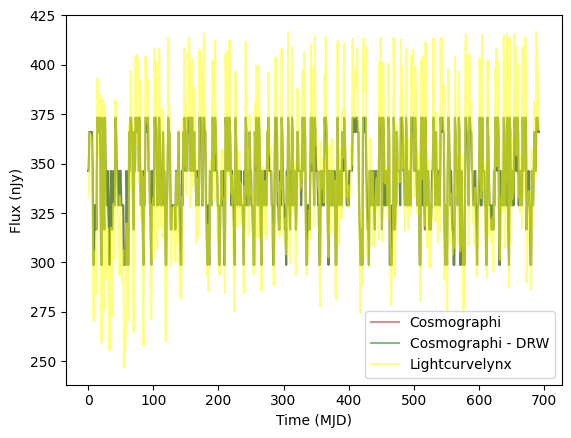

In [ ]:
plt.plot(my_model_flux_comparable_units, color="brown", label="Cosmographi", alpha=0.5)
plt.plot(model_flux_comparable_units2, color="green", label="Cosmographi - DRW", alpha=0.5)
plt.plot(flux, color='yellow', label="Lightcurvelynx", alpha=0.5)
plt.xlabel("Time (MJD)")
plt.ylabel("Flux (nJy)")
plt.legend()
plt.show()